In [1]:
# This script uses a AIRflows PRO .nc file
# and MetUM archive (*.pp) files to interpolate a field
# from a MetUM forecast (e.g. vertical wind)
# to the flight path from the TUBS Cessna
# and produce "curtain" plots of 
# MetUM and observed fields

# import libraries
import glob
import iris
import pyresample as pyre
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from time import strftime, gmtime

In [2]:
# specify the directory containing the MetUM archive files
umdir = '/gws/ssde/j25b/team_x/users/kahern/hackathon/metum/20250629T1200Z'

# model initialization string
uminit = '20250629T1200Z'

# what is the forecast init?
umdd = 29  # initialization day
umhh = 12  # initialization hour

# specify the AIRflows profile file
affile = '/gws/ssde/j25b/team_x/users/kahern/hackathon/airflows/PRO_20250630_100_combined.nc'

# target heights (m) to interpolate flight & model data to
targz = list(range(50, 4001, 50))

In [3]:
# pull AIRflows profile data
afattr = xr.open_dataset(affile, engine="netcdf4")
afdata = xr.open_dataset(affile, engine="netcdf4", group="combined")
flylon = np.float64(afdata["AER_lon_avg"].values)  # aircraft longitude (deg)
flylat = np.float64(afdata["AER_lat_avg"].values)  # aircraft latitude (deg)
flyalt = np.float64(afdata["AER_alt_avg"].values)  # aircraft altitude (m)
scanalt = np.float64(afdata["GEO_alt_avg"].values)  # altitude of data retrieval (m)
orogavg = afdata["TOP_avg"].values  # average orography in scan (m)
orogmin = afdata["TOP_min"].values  # minimum orog in scan
orogmax = afdata["TOP_max"].values  # maximum orog in scan
rawu = afdata["u"].values  # zonal wind (m/s)
rawv = afdata["v"].values  # meridional wind (m/s)
raww = afdata["w"].values  # vertical wind (m/s)
rawwspd = afdata["ff_hor"].values  # horizontal wind speed (m/s)

In [4]:
# get the timestamps of the start and end of the flight data
fpostime = afdata["AER_posixtime"].values
itime    = pd.to_datetime(strftime('%Y-%m-%d %H:%M:%S', gmtime(fpostime[0])))
ftime    = pd.to_datetime(strftime('%Y-%m-%d %H:%M:%S', gmtime(np.nanmax(fpostime))))

# given the data record start, what is the 1st
# forecast hour to pull MetUM data from?
iday    = itime.day
ihour   = itime.hour
if ihour < 0:
    ihour = ihour + 24
    iday  = iday - 1
ifcsthr = ((iday - umdd) * 24) + (ihour - umhh)

# given the data record end, what is the last
# forecast hour to pull MetUM data from?
fday    = ftime.day
fhour   = ftime.hour + 1
if fhour >= 24:
    fhour = fhour - 24
    fday  = fday + 1
ffcsthr = ((fday - umdd) * 24) + (fhour - umhh)

# print them for clarity
print(f"Earliest forecast hour to pull: {ifcsthr}")
print(f"Latest forecast hour to pull:   {ffcsthr}")

# the number of forecast hours to use
tsize = ffcsthr - ifcsthr + 1

Earliest forecast hour to pull: 20
Latest forecast hour to pull:   24


In [5]:
# use pattern matching to find any MetUM archives
# in the specified input directory.
allfiles = glob.glob(f"{umdir}/*_pexpc*.pp")
allfiles.append(glob.glob(f"{umdir}/*_pa000.pp")[0])
allfiles.sort()

In [6]:
# We will need height data, which is typically included
# as an auxiliary coordinate in cubes for data with
# a vertical dimension. Let's try to interpolate vertical wind.

# Load the cube(s) with vertical wind data for the
# forecast hours we're interested in.
fcstpr = list(range(ifcsthr, ffcsthr+1, 1))  # forecast hrs we're interested in
cons = iris.Constraint(name="upward_air_velocity", forecast_period=fcstpr)
cubes = iris.load(allfiles, constraints=cons)
um_w = cubes[0].data  # UM vertical wind data (m/s)

In [7]:
# Pull the altitude data from the vertical wind cube.
# The result will be altitude above sea level
# on the model grid.
zarr = cubes[0].coord("altitude").points

In [8]:
# let's also load orography (height above sea level) from the model
orogfile = glob.glob(f"{umdir}/*_pa000.pp")[0]
cons = iris.Constraint(name="surface_altitude")
cubes = iris.load(orogfile, constraints=cons)
umsfchgt = cubes[0].data

In [9]:
# let's get lon/lat grids from the model
cs_nat = cubes[0].coord_system()
cs_nat_cart = cs_nat.as_cartopy_projection()
cs_tgt = iris.coord_systems.GeogCS(iris.analysis.cartography.DEFAULT_SPHERICAL_EARTH_RADIUS)
cs_tgt_cart = cs_tgt.as_cartopy_projection()

proj_x = cubes[0].coord('grid_longitude').points
proj_y = cubes[0].coord('grid_latitude').points
xx, yy = np.meshgrid(proj_x, proj_y)

umlons, umlats, _ = cs_tgt_cart.transform_points(cs_nat_cart, xx, yy).T
umlons = np.transpose(umlons)
umlats = np.transpose(umlats)

In [10]:
# First, we will interpolate the flight data to the specified height
# levels we defined in targz earlier

print("   Calculating flight weights for vertical interp...")

# z-indices and weights to do vertical interpolations of flight data
fku = np.zeros((scanalt.shape[0], len(targz)), dtype=int)
fkl = np.zeros((scanalt.shape[0], len(targz)), dtype=int)
fwu = np.empty((scanalt.shape[0], len(targz)))
fwl = np.empty((scanalt.shape[0], len(targz)))

for k in range(len(targz)):
    tz = targz[k]
    # get the diffs between heights at each level and the target height
    dz = tz - scanalt

    # maskout all data where dz is negative
    posmask = (dz < 0)
    posdz = np.ma.masked_array(dz, mask=posmask)
    negmask = (dz > 0)
    negdz = np.ma.masked_array(dz, mask=negmask)

    for n in range(dz.shape[0]):
        # get an array of the z-indices where non-negative dz is smallest
        try:
            posidx = np.nanargmin(posdz[n,:])
            negidx = np.nanargmax(negdz[n,:])
        except ValueError:
            fku[n, k] = -1
            fkl[n, k] = -1
            fwu[n, k] = np.nan
            fwl[n, k] = np.nan
            continue

        zu = scanalt[n, negidx]  # negative dz means zarr is above tz
        zl = scanalt[n, posidx]  # positive dz means zarr is below tz
        # check: zu (z-upper) should be above (greater than) tz
        #        zl should be below (less than) tz
        if zu >= tz and zl <= tz:
            fku[n, k] = negidx
            fkl[n, k] = posidx
            interdz = dz[n, fkl[n, k]] - dz[n, fku[n, k]]
            fwu[n, k] = 1.0 - (-dz[n, fku[n, k]] / interdz)
            fwl[n, k] = 1.0 - ( dz[n, fkl[n, k]] / interdz)
        else:
            fku[n, k] = -1
            fkl[n, k] = -1
            fwu[n, k] = np.nan
            fwl[n, k] = np.nan

   Calculating flight weights for vertical interp...


/tmp/ipykernel_9530/786361691.py:40: RuntimeWarning: invalid value encountered in scalar divide
  fwu[n, k] = 1.0 - (-dz[n, fku[n, k]] / interdz)
/tmp/ipykernel_9530/786361691.py:41: RuntimeWarning: invalid value encountered in scalar divide
  fwl[n, k] = 1.0 - ( dz[n, fkl[n, k]] / interdz)


In [11]:
# function to interpolate flight data
# to specified height levels
def interpflight(field):
    # vertically interpolate flight profile data
    rarr = np.empty((scanalt.shape[0], len(targz)), dtype=float)
    for n in range(rarr.shape[0]):
        for k in range(rarr.shape[1]):
            if fku[n, k] < 0:
                rarr[n, k] = np.nan
            else:
                rarr[n, k] = (fwu[n, k] * field[n, fku[n, k]]) \
                    + (fwl[n, k] * field[n, fkl[n, k]])
    return rarr

In [12]:
# interpolate the observed vertical wind field
# to specified height levels
flightw = interpflight(raww)

In [13]:
# calculate the profile-mean orography detected by the aircraft
meanorog = np.nanmean(orogavg, axis=1)

# We can do a bit of array manipulation to get the
# height of a given level relative to the observed orography
# Use meshgrid to make 2-D arrays of the height levels
# we are interpolating data onto and the observed orography;
# the 1st dimension of these arrays is the flight record,
# and the 2nd dimension of these arrays is the vertical level
levsarray, orogarray = np.meshgrid(targz, meanorog)

# take the difference between the two arrays to get
# height relative to the observed orography
obshgtagl = levsarray - orogarray

/tmp/ipykernel_9530/828447464.py:2: RuntimeWarning: Mean of empty slice
  meanorog = np.nanmean(orogavg, axis=1)


In [14]:
# Next, we will vertically interpolate the model data to the specified height
# levels we defined in targz earlier, and also horizontally interpolate the data
# to the flight path
print("   Calculating model weights for vertical interp...")

# z-indices and weights to do vertical interpolations of model data
ku = np.zeros((len(targz), zarr.shape[1], zarr.shape[2]), dtype=int)
kl = np.zeros((len(targz), zarr.shape[1], zarr.shape[2]), dtype=int)
wu = np.empty((len(targz), zarr.shape[1], zarr.shape[2]))
wl = np.empty((len(targz), zarr.shape[1], zarr.shape[2]))

for k in range(len(targz)):
    tz = targz[k]
    # get the diffs between heights at each level and the target height
    dz = tz - zarr

    # maskout all data where dz is negative
    posmask = (dz < 0)
    posdz = np.ma.masked_array(dz, mask=posmask)
    negmask = (dz > 0)
    negdz = np.ma.masked_array(dz, mask=negmask)

    # get an array of the z-indices where non-negative dz is smallest
    posidx = np.nanargmin(posdz, axis=0)
    negidx = np.nanargmax(negdz, axis=0)

    for j in range(posidx.shape[0]):
        for i in range(posidx.shape[1]):
            zu = zarr[negidx[j, i], j, i]  # negative dz means zarr is above tz
            zl = zarr[posidx[j, i], j, i]  # positive dz means zarr is below tz
            # check: zu (z-upper) should be above (greater than) tz
            #        zl should be below (less than) tz
            if zu >= tz and zl <= tz:
                ku[k, j, i] = negidx[j, i]
                kl[k, j, i] = posidx[j, i]
                interdz = dz[kl[k, j, i], j, i] - dz[ku[k, j, i], j, i]
                wu[k, j, i] = 1.0 - (-dz[ku[k, j, i], j, i] / interdz)
                wl[k, j, i] = 1.0 - ( dz[kl[k, j, i], j, i] / interdz)
            else:
                ku[k, j, i] = -1
                kl[k, j, i] = -1
                wu[k, j, i] = np.nan
                wl[k, j, i] = np.nan

   Calculating model weights for vertical interp...


/tmp/ipykernel_9530/3376783806.py:34: RuntimeWarning: invalid value encountered in scalar divide
  wu[k, j, i] = 1.0 - (-dz[ku[k, j, i], j, i] / interdz)
/tmp/ipykernel_9530/3376783806.py:35: RuntimeWarning: invalid value encountered in scalar divide
  wl[k, j, i] = 1.0 - ( dz[kl[k, j, i], j, i] / interdz)


In [15]:
# In the horizontal sense, we will bilinearly interpolate points from MetUM
# to the location of each record in the AIRflows data.
# The interpolation will need 4 (i,j) pairs
# for the 4 points closest to each AIRflows record:
# one to the southwest of the AIRflows record,
# one to the southeast of the AIRflows record,
# one to the northwest of the AIRflows record, and
# one to the northeast of the AIRflows record.

# these are the (i,j) pairs associated with the SW corners (bounds)
# of the 4-point clusters of data to interpolate from MetUM
boundimin = np.zeros(flylon.shape[0], dtype=int)
boundjmin = np.zeros(flylon.shape[0], dtype=int)

# weights to apply to MetUM datapoints in the bilinear interpolation
wSW = np.empty(flylon.shape[0], dtype=float)
wSE = np.empty(flylon.shape[0], dtype=float)
wNW = np.empty(flylon.shape[0], dtype=float)
wNE = np.empty(flylon.shape[0], dtype=float)

In [16]:
# define the lat-lon grid of the MetUM domain
umgrid = pyre.geometry.GridDefinition(lats=umlats, lons=umlons)
# define the lat-lon swath of the flight path
flyswath = pyre.geometry.SwathDefinition(lons=flylon, lats=flylat)

# for each point in the swath of flight data,
# determine nearest neighbor on the MetUM grid
# using great-circle distance
_, _, index_array, distance_array = pyre.kd_tree.get_neighbour_info(
    source_geo_def=umgrid, target_geo_def=flyswath, radius_of_influence=50000,
    neighbours=1)

# array of indices (j,i) of the MetUM gridpoints that
# are closest to each point in the flight path
index_array_2d = np.unravel_index(index_array, umgrid.shape)

In [17]:
print("   Calculating model weights for horizontal interp...")

i   = 0
idx = 0
while i < flylon.shape[0]:
    if np.isnan(flylon[i]) or np.isnan(flylat[i]):
        i = i + 1
        continue

    alon = np.float64(flylon[i])
    alat = np.float64(flylat[i])

    # get i and j of the model gridpoint closest to aircraft location
    # as well as the actual distance to check it's close enough
    imin = index_array_2d[1][idx]
    jmin = index_array_2d[0][idx]
    mindist = distance_array[idx]

    if mindist < 2000.0:
        if imin > 0 and imin < umlons.shape[1]-1 and jmin > 0 and jmin < umlons.shape[0]-1:
            # where is the aircraft relative to the nearest model gridpoint?
            londiff = flylon[i] - umlons[jmin, imin]
            latdiff = flylat[i] - umlats[jmin, imin]
            # we need to identify which i,j are associated with the 
            # southwestern corner of the 2x2 grid to interpolate data
            # from
            if londiff >= 0.0 and latdiff >= 0.0:
                # aircraft northeast of nearest gridpoint
                # that means the southwestern corner of the 2x2
                # grid to interpolate data from is the same gridpoint
                # that is closest to the aircraft
                boundimin[i] = imin
                boundjmin[i] = jmin
            elif londiff >= 0.0 and latdiff < 0.0:
                # aircraft southeast of nearest gridpoint
                # southwestern corner of the 2x2 grid is 1
                # gridpoint "south" of gridpoint closest to aircraft
                boundimin[i] = imin
                boundjmin[i] = jmin - 1
            elif londiff < 0.0 and latdiff >= 0.0:
                # aircraft northwest of nearest gridpoint
                # southwestern corner of the 2x2 grid is 1
                # gridpoint "west" of gridpoint closest to aircraft
                boundimin[i] = imin - 1
                boundjmin[i] = jmin
            elif londiff < 0.0 and latdiff < 0.0:
                # aircraft southwest of nearest gridpoint
                # southwestern corner of the 2x2 grid is 1
                # gridpoint "south" and "west" of gridpoint closest to aircraft
                boundimin[i] = imin - 1
                boundjmin[i] = jmin - 1

            # approximate the areas of the rectangles bounded
            # by the flight datum in one corner, and model data in
            # diagonally opposing corners
            er = 6371000.0
            d2r = np.pi/180.0
            # the approximate area of the rectangle bounded by the
            # flight datum in one corner and the model datum
            # that lies nearest to the southwest of the flight datum
            aSW = abs(umlons[boundjmin[i], boundimin[i]] - alon) \
                * abs(umlats[boundjmin[i], boundimin[i]] - alat) \
                * pow(d2r * er, 2) * np.cos(alat*d2r)
            # same as above, but using the model datum that lies
            # nearest to the southeast of the flight datum
            aSE = abs(umlons[boundjmin[i], boundimin[i]+1] - alon) \
                * abs(umlats[boundjmin[i], boundimin[i]+1] - alat) \
                * pow(d2r * er, 2) * np.cos(alat*d2r)
            # ... using nearest to the northwest...
            aNW = abs(umlons[boundjmin[i]+1, boundimin[i]] - alon) \
                * abs(umlats[boundjmin[i]+1, boundimin[i]] - alat) \
                * pow(d2r * er, 2) * np.cos(alat*d2r)
            # ... and using nearest to the northeast
            aNE = abs(umlons[boundjmin[i]+1, boundimin[i]+1] - alon) \
                * abs(umlats[boundjmin[i]+1, boundimin[i]+1] - alat) \
                * pow(d2r * er, 2) * np.cos(alat*d2r)

            # the sum of the areas calculated
            aSUM = aSW + aSE + aNW + aNE
            # the weight assigned to the model gridpoint nearest southwest
            # of the flight datum is proportional to the area of the rectangle
            # calculated using the model gridpoint nearest northeast (opposite)
            # of the flight datum
            wSW[i] = aNE / aSUM
            # weight of the model gridpoint to the southeast is proportional
            # to the area of the rectangle calculated using the model grid point
            # to the northwest ...
            wSE[i] = aNW / aSUM
            # northwest weight uses area from the southeast model gridpoint ...
            wNW[i] = aSE / aSUM
            # northeast weight uses area from the southwest model gridpoint 
            wNE[i] = aSW / aSUM

    i = i + 1
    idx = idx + 1

   Calculating model weights for horizontal interp...


In [18]:
# function to interpolate flat (no vertical dimension)
# MetUM fields to a point on the flight path

# fbound is the 2x2 array of model data closest
# to the flight path to interpolate bilinearly;
# widx is the index to use with the weights for the
# four model grid points
def interpsfc(fbound, widx):
    # bilinearly interpolate data
    # and return a scalar result
    rarr = (wSW[widx] * fbound[0, 0]) \
            + (wSE[widx] * fbound[0, 1]) \
            + (wNW[widx] * fbound[1, 0]) \
            + (wNE[widx] * fbound[1, 1])
    return rarr

In [19]:
# function to interpolate volumetric MetUM fields 
# to a sounding (vertical profile) on the flight path
def interp2sounding(fbound, widx):
    # get the weights for vertically interpolating
    # data in the 2x2 model data column
    kubound = ku[:, boundjmin[widx]:boundjmin[widx]+2, boundimin[widx]:boundimin[widx]+2]
    klbound = kl[:, boundjmin[widx]:boundjmin[widx]+2, boundimin[widx]:boundimin[widx]+2]
    wubound = wu[:, boundjmin[widx]:boundjmin[widx]+2, boundimin[widx]:boundimin[widx]+2]
    wlbound = wl[:, boundjmin[widx]:boundjmin[widx]+2, boundimin[widx]:boundimin[widx]+2]

    # vertically interpolate data in the 2x2 column
    zintarr = np.empty((len(targz),fbound.shape[1],fbound.shape[2]),dtype=float)
    for k in range(zintarr.shape[0]):
        for j in range(zintarr.shape[1]):
            for i in range(zintarr.shape[2]):
                if kubound[k,j,i] < 0:
                    zintarr[k,j,i] = np.nan
                else:
                    zintarr[k,j,i] = (wubound[k,j,i] * fbound[kubound[k,j,i],j,i]) \
                        + (wlbound[k,j,i] * fbound[klbound[k,j,i],j,i])

    # horizontally interpolate the vertically interpolated 2x2 column 
    # at each level to make a sounding, and then return it
    rarr = np.empty((len(targz)),dtype=float)
    for k in range(zintarr.shape[0]):
        rarr[k] = (wSW[widx] * zintarr[k,0,0]) \
                        + (wSE[widx] * zintarr[k,0,1]) \
                        + (wNW[widx] * zintarr[k,1,0]) \
                        + (wNE[widx] * zintarr[k,1,1])

    return rarr

In [20]:
# let's interpolate the model orography to the flight path
print("   Interpolating model orography...")
ovar = np.empty((boundimin.shape[0]), dtype=float)
for i in range(boundimin.shape[0]):
    dbound = umsfchgt[boundjmin[i]:boundjmin[i]+2, boundimin[i]:boundimin[i]+2]
    sfcval = interpsfc(dbound, i)
    ovar[i] = sfcval
# ovar is now a 1-D array of the model orography
# interpolated to points on the flight path.

   Interpolating model orography...


In [ ]:
# Similar to earlier,
# we can do some array manipulation to get the
# height of a given level relative to the interpolated
# orography (umhgtagl)
# Use meshgrid to make 2-D arrays of the height levels
# we are interpolating data onto and
# the interpolated model orography;
# the 1st dimension of these arrays is the flight record,
# and the 2nd dimension of these arrays is the vertical level
levsarray, orogarray = np.meshgrid(targz, ovar)
# take the difference between the two arrays to get
# height relative to the interpolated model orography
umhgtagl = levsarray - orogarray

In [23]:
# interpolate the model vertical wind to profiles (soundings)
# along the flight path
print("   Interpolating model vertical wind...")
modelw = np.empty((tsize, boundimin.shape[0], len(targz)), dtype=float)
for t in range(ifcsthr, ffcsthr+1):
    k = ifcsthr - t
    cdata = um_w[k, :, :, :]
    for i in range(boundimin.shape[0]):
        dbound = cdata[:, boundjmin[i]:boundjmin[i]+2, boundimin[i]:boundimin[i]+2]
        sndg = interp2sounding(dbound, i)
        modelw[k, i, :] = sndg
# modelw is now a 3-D array of the model vertical wind
# interpolated to specified heights and horizontal locations of data 
# on the flight path.
# The first dimension of the array represents the forecast hour relative
# to the first forecast hour we pulled data for earlier (ifcsthr)
print(modelw.shape)

   Interpolating model vertical wind...
(5, 9888, 80)


Text(0, 0.5, 'Altitude above sea level [m]')

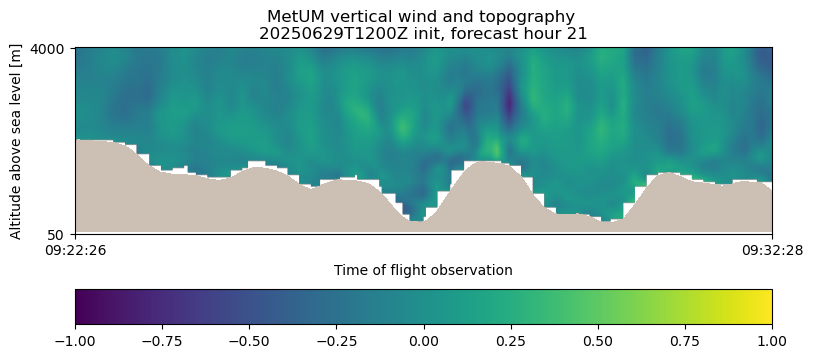

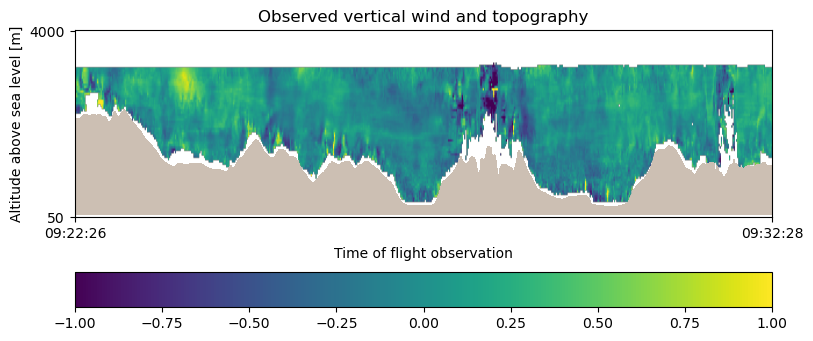

In [35]:
# let's try to draw the vertical wind curtain plots
# first let's draw the MetUM vertical wind
plotti = 1100  # which flight record to start with in the curtain plot?
plottf = 1700  # which flight record to end on in the curtain plot?

# get timestamps of the flight records at the start and end
tistamp = pd.to_datetime(strftime('%H:%M:%S', gmtime(fpostime[plotti])))
tfstamp = pd.to_datetime(strftime('%H:%M:%S', gmtime(fpostime[plottf])))
tistamp = f"{tistamp.hour:02d}:{tistamp.minute:02d}:{tistamp.second:02d}"
tfstamp = f"{tfstamp.hour:02d}:{tfstamp.minute:02d}:{tfstamp.second:02d}"

# let's plot MetUM vertical wind
# from the second forecast hour we pulled data for (ifcsthr+1)
plotarr = modelw[1, :, :]

# draw the curtain plot of MetUM vertical velocity
fig = plt.figure(figsize=(9, 4.8))
ax = fig.add_subplot()
ax.set_title(f"MetUM vertical wind and topography \n20250629T1200Z init, forecast hour {ifcsthr+1}")
plt.imshow(plotarr[plotti:plottf,::-1].T, vmin=-1, vmax=1) 
plt.colorbar(orientation='horizontal')

# let's also draw a colorfill on the curtain plot
# wherever the height of a vertical level is below
# the model orography
plt.contourf(umhgtagl[plotti:plottf,::-1].T, levels=[-9999, 0, 9999], colors=[(0.8,0.75,0.7,1), (0,0,0,0)])

# stretch the vertical axis
ax.set_aspect(aspect=2)

# define the number of x-axis ticks (2) and draw timestamps on them
xticks = np.arange(0, plottf-plotti+1, plottf-plotti)
xlabels = [tistamp, tfstamp]
ax.set_xticks(xticks, labels=xlabels)

# define the number of y-axis ticks (2) and draw height limits on them
yticks = np.arange(0, plotarr.shape[1]+1, plotarr.shape[1])
ylabels = [targz[-1], targz[0]]
ax.set_yticks(yticks, labels=ylabels)


# draw x-, y-axis labels
plt.xlabel('Time of flight observation')
plt.ylabel('Altitude above sea level [m]')

# Repeat the process above,
# but draw a curtain plot of the observed vertical wind and orography
fig = plt.figure(figsize=(9, 4.8))
ax = fig.add_subplot()
ax.set_title("Observed vertical wind and topography")
plt.imshow(flightw[plotti:plottf,::-1].T, vmin=-1, vmax=1)
plt.colorbar(orientation='horizontal')
plt.contourf(obshgtagl[plotti:plottf,::-1].T, levels=[-9999, 0, 9999], colors=[(0.8,0.75,0.7,1), (0,0,0,0)])
ax.set_aspect(aspect=2)
xticks = np.arange(0, plottf-plotti+1, plottf-plotti)
xlabels = [tistamp, tfstamp]
ax.set_xticks(xticks, labels=xlabels)
yticks = np.arange(0, plotarr.shape[1]+1, plotarr.shape[1])
ylabels = [targz[-1], targz[0]]
ax.set_yticks(yticks, labels=ylabels)
plt.xlabel('Time of flight observation')
plt.ylabel('Altitude above sea level [m]')